### Projeto

## Modelo de Classificação Para Análise de Sentimentos

**1. Definição do Problema de Negócio**

É a fundamentação do projeto. Nesta etapa, truduzimos uma necessidade da empresa em um objetivo claro para a ciência de dados. Definimos o que queremos resolver (automatizar a classificação de reviews de produtos, por exemplo), porque é importante (reduzir custos, agilizar a tomada de decisão) e como o sucesso será medido.

**Definição**

Uma empresa de e-commerce deseja automatizar a análise de feedbacks de seus clientes. Atualmente, a análise é feita manualmente, o que é um processo lento, caro e que não escala com o volume de reviews revebidos diariamente.

**Objetivo:**

Criar um modelo de machine learning que classifique automaticamente os reviews de produtos como 'positivo' ou 'negativo'.

**Benefícios Esperados:**

 - Eficiência: Reduzir o tempo e o custo da análise de feedback.
 - Tomada de decisão rápida: Permitir que as equipes de produto e marketing identifiquem rapidamente produtos  com problemas ou oportunidades de melhoria.
 - Priorização: Direcionar reviews negativos para a equipe de suporte ao cliente de forma prioritária, melhorando a experiência do consumidor.

 **2. Importação dos Pacotes**

 Esta é a fase de preparação do ambiente de trabalho. Aqui, carregamos todas as ferramentas e bibliotecas Python necessárias ( como Pandas para a manipulação de dados, Scikit-learn para modelagem e Matplotlib/Seaborn para visualização) que serão utilizadas ao longo do projeto.

In [4]:
# Manipulação de Dados e Visualização
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [5]:
# Configuração de Visualização
sns.set_style('whitegrid')
%matplotlib inline

In [6]:
%reload_ext watermark
%watermark -a "Leonardo da Silva Neves"

Author: Leonardo da Silva Neves



In [7]:
%watermark --iversions

joblib    : 1.5.3
matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.8.0



**3. Carregando e Compreendendo os Dados**

É o primeiro contato com matéria-prima do projeto. Lemos os dados de uma fonte (no nosso caso, um arquivo CSV) para um DataFrame do Pandas e realizamos uma verificação inicial para entender sua estrutura.

In [8]:
# Define o nome do arquivo
file = 'dataset.csv'

In [9]:
# Carrega o dataset
df = pd.read_csv(file)

In [10]:
# Shape
df.shape

(500, 3)

In [11]:
# Primeiras Linhas
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [13]:
# Amostra dos dados
df.sample(10)

,review_id,texto_review,sentimento
292,293,Estou muito impressionado com a compra. O moni...,positivo
211,212,Amei o mouse! A qualidade é fantástica e a ent...,positivo
470,471,Simplesmente perfeito! O monitor funciona muit...,positivo
165,166,Péssima experiência. O notebook quebrou no pri...,negativo
103,104,Ótimo custo-benefício. O celular é fantástica ...,positivo
289,290,Amei o livro! A qualidade é excelente e a entr...,positivo
59,60,Ótimo custo-benefício. O notebook é muito boa ...,positivo
450,451,Odiei o livro. Qualidade decepcionante e veio ...,negativo
132,133,Estou muito arrependido com esta compra. Dinhe...,negativo
47,48,Estou muito satisfeito com a compra. O mouse é...,positivo


In [14]:
# Últimas linhas
df.tail()

,review_id,texto_review,sentimento
495,496,Odiei o teclado. Qualidade de baixa qualidade ...,negativo
496,497,Estou muito impressionado com a compra. O moni...,positivo
497,498,Não recomendo. A entrega demorou uma eternidad...,negativo
498,499,Estou muito arrependido com esta compra. Dinhe...,negativo
499,500,Ótimo custo-benefício. O cadeira gamer é incrí...,positivo


**4. Análise Exploratória de Dados**

A fase de investigação. Aqui, "mergulhamos" nos dados para descobrir padrões, anomalias e insights. Utilizamos gráficos (como a contagem de sentimentos positivos vs. negativos) e estatísticas para entender a distribuição e as características dos dados antes de qualquer modificação.

In [15]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     500 non-null    int64 
 1   texto_review  488 non-null    object
 2   sentimento    500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB


In [16]:
print("\nVerificando Valores Ausentes:\n")
print(df.isnull().sum())


Verificando Valores Ausentes:

review_id        0
texto_review    12
sentimento       0
dtype: int64



Distribuição dos Sentimentos



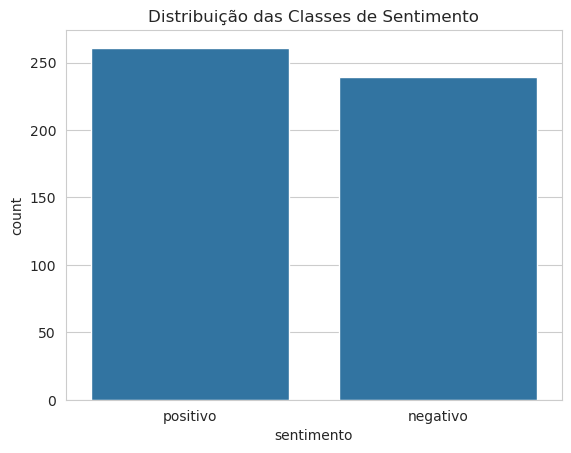

In [17]:
print("\nDistribuição dos Sentimentos\n")
sns.countplot(x = 'sentimento', data = df)
plt.title('Distribuição das Classes de Sentimento')
plt.show()

**5. Limpeza de Dados**

Nesta etapa corrigimos os problemas identificados na EDA. Isso inclui tratar valores ausentes (por exemplo, removendo as linhas correspondentes), garantir que os dados estejam no formato correto e aplicar a função de limpeza de texto (dsa_limpa_texto) para normalizar os reviews, removendo acentos, pontuações e caracteres indesejados.

In [21]:
# Remover linhas com valores ausentes
print(f"\nTamanho original do DataFrame: {len(df)}")
df.dropna(subset = ['texto_review'], inplace = True)
print(f"Tamanho do DataFrame após remoção dos valores nulos: {df.shape[0]}")


Tamanho original do DataFrame: 488
Tamanho do DataFrame após remoção dos valores nulos: 488


In [19]:
df.shape

(488, 3)

In [20]:
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo


In [23]:
# Função de limpeza de texto
def limpa_texto(texto):

    """
    Função completa de limpeza de texto:
    1. Converte para minúsculo.
    2. Remove acento e cedilha.
    3. Remove pontuação, números e caracteres especiais.
    4. Remove espaços extras.
    """

    # Garante que o texto não seja nulo (caso haja algum NaN no DataFrame)
    if not isinstance(texto, str):
        return ""

    # --- PASSO 1: Normalizar e remover acentos ---
    # Normalizar para a forma 'NFKD' que separa o caracter da acentuação
    # e depois remove os acentos (Nonspacing Mark)
    texto_sem_acentos = ''.join(c for c in unicodedata.normalize('NFKD', texto) if unicodedata.category(c) != 'Mn')

    # PASSO 2: Limpeza com Regex ---
    # Converter para minúsculas
    texto_limpo = texto_sem_acentos.lower()

    # Manter apenas letras e espaços. A remoção de acentos já foi feita.
    texto_limpo = re.sub(r'[^a-z\s]', '', texto_limpo)

    # Remove espaços extras
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo.strip())

    return texto_limpo